In [1]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1"]
nfaillinks_list_dict = dict()
nfaillinks_list_dict["leafspine_before"] = [1,3,4,6,8]
nfaillinks_list_dict["dringsu2_before"] = [1,3,4,6,8]
nfaillinks_list_dict["dringsu2_after"] = [1,3,4,6,8]
fseed_list = range(10)
scheme_list = ["dringsu2_before","leafspine_before","dringsu2_after"]
failpct_list = [0,2,4,6,8,10]
load_dict = dict()
load_dict["unv1"] = 4
load_dict["prv1"] = 4
seed = 1

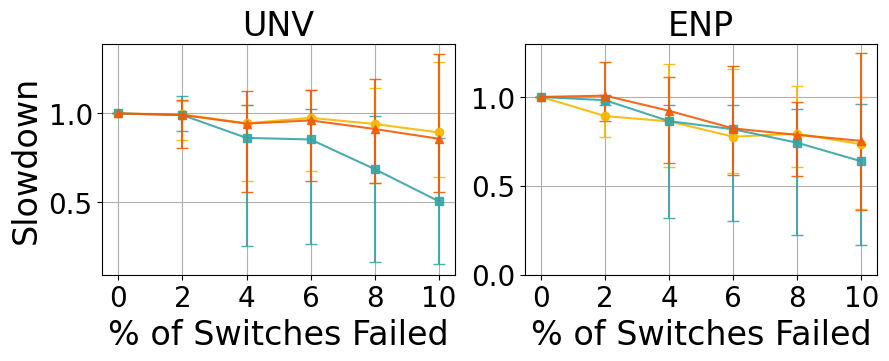

In [ ]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2_after":"Starfish (Failure-Aware)","dringsu2_before":"Starfish","leafspine_before":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2_after":"#f35b04","leafspine_before":"#38a3a5","dringsu2_before":"#f7b801"}


plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()
        plotevalmaindatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*3))
for ic,cm in enumerate(cm_list):
    for isc,scheme in enumerate(scheme_list):
        fct_list = list()
        load = load_dict[cm]
        fct_list_allseeds = list()
        if "dring" in scheme:
            myscheme = "dringsu2"
        else:
            myscheme = "leafspine"
        outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
        p99_baseline = plotevalmaindatadict[cm][outfile]
        fct_list_allseeds.append(1)
        fct_list.append(fct_list_allseeds)

        for nfaillinks in nfaillinks_list_dict[scheme]:
            fct_list_allseeds = list()
            for fseed in fseed_list:
                outfile = f"{cm}/outfiles/{scheme}_nfailtor{nfaillinks}_fseed{fseed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99/p99_baseline)
            fct_list.append(fct_list_allseeds)
        
        if ic==0:
            axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=plotmarkers[isc], label=plotlabeldict[scheme],alpha=0.9, capsize=4, color=plotcolordict[scheme])
        else:
            axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=plotmarkers[isc],alpha=0.9, capsize=4, color=plotcolordict[scheme])

        # print(f"{cm},{scheme}: {fct_list}")
    
    axs[ic].set_xlabel("% of Switches Failed", fontsize=24)
    axs[ic].set_title(plottitledict[cm], fontsize=24)
    axs[ic].tick_params(axis='both', labelsize=20)
    axs[ic].grid(True)
    axs[ic].set_xticks([0, 2, 4, 6, 8, 10])
    axs[ic].set_yticks()

axs[0].set_ylabel("Slowdown", fontsize=24)
# axs[0].set_yticks(range(0,13,4))
axs[1].set_ylim(0,None)
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.27), ncol=2, fontsize=22)
plt.savefig(f"talk_failure_tor.pdf", dpi=600, bbox_inches='tight')